# Linear model selection and model regularization
----
선형모형을 다시 돌아보자.

$$ Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + \epsilon $$

선형모형은 간단함에도 불구하고, interpretablity가 좋고, 종종 좋은 predictive performance를 보인다.

이 장에서는 선형모형의 기본적인 장점은 유지하면서 단점을 보완하는 대안들을 살펴본다.

* Prediction accuracy : $p > n$이면 최소제곱 회귀계수가 유일하게 결정되지 않을 수 있다. 또한 설명변수가 많으면 과적합이 발생하기 쉽다. 추정될 모수의 수를 제한하여 추정량의 분산을 줄이고 예측 정확성을 높인다. 설명변수가 많거나 서로 강하게 상관되어 있으면 최소제곱 추정량의 변동성이 커질 수 있는데, 정규화는 약간의 bias를 허용하는 대신 추정량의 분산을 줄일 수 있다.

* Model interpretability : 불필요한 feature 변수를 제외하여 모형을 보다 해석 가능하도록 만든다. feature selection 혹은 variable selection이 자동으로 이루어지는 방법에 대해 알아본다.

* Subset selection : $p$개의 predictor 중에서 반응변수와 연관이 있을 것으로 생각되는 부분 집합을 식별하는 방법.

* Shrinkage (regularization) : $p$개의 predictor를 모형 적합에 사용하지만, 그 중의 일부 predictor들의 해당되는 계수는 0 혹은 0과 매우 가까운 값으로 추정된다. 

* Dimension reduction : $p$개의 predictor를 $M$-dimensional subspace로 투영하는 방법.

## Subset selection

$p$개의 predictor가 있을 때, $k=1, 2, \cdots, p$에 대하여 다음을 실행한다.

* 각 $k$에 대하여 정확히 $\binom{p}{k}$개의 가능한 모형이 있다. 이 모형들에 대해 모두 적합을 진행한다.

  * 각 $k$에 대하여 적합된 모형 중 가장 적합이 잘된 모형이 있을 것이다. 이를 $\mathcal M_k$라 하자.
  
  * 한편 predictor가 없는 단순한 평균 모형은 $\mathcal M_0$라고 하겠다.
  
* $\mathcal M_0, \mathcal M_1, \cdots, \mathcal M_p$ 중에서 best인 모형을 찾는다. 

  * Best를 찾기 위해서 cross-validated prediction error, $C_p$ (AIC), BIC 혹은 adjusted $R^2$ 등이 이용될 수 있다.

## Shrinkage methods

적절한 constraint 혹은 regularization 방법을 통해 불필요한 추정치를 0으로 가깝게 만드는 방법이다.

### Ridge regression

Least square 방식을 다시 돌아보자. 이 방법에서는 다음을 최소화하는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \mathrm{RSS} = \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 $$

반면 ridge regression에서는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 = \mathrm{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2 $$

- 여기서 $\lambda \geq 0 $으로 tuning parameter라고 불리운다.

절편에는 일반적으로 penalty를 적용하지 않는다.

위 식에서 $\beta$들의  추정량을 $\hat \beta^{R}$이라 하겠다.

$\lambda \sum_{j=1}^{p} \beta_j^2$는 shrinkage penalty라고 불리우며, $\beta$들이 0에 가까울수록 작아진다.

적절한 $\lambda$를 선택하는 것이 중요하며 이는 cross-validation 방법을 통해 선택할 수 있다.

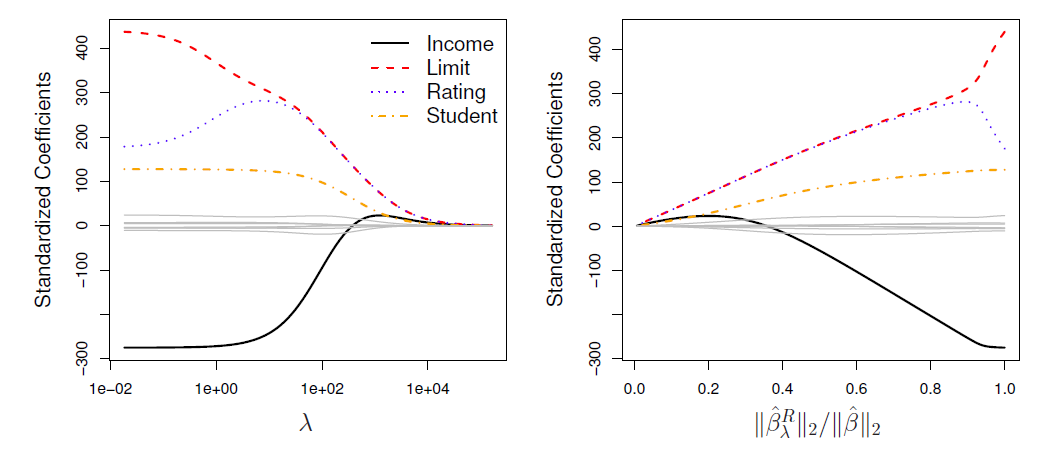

위 그림의 왼쪽에서 보듯 $\lambda$가 커지면 결국 모든 $\beta$들의 추정치는 0에 가까워진다.

오른쪽 그림에서는 x-축에 $ \dfrac{|| \hat \beta_\lambda^R ||_2}{|| \hat \beta ||_2} $를 표현하였다.

여기서 $|| \cdot ||_2$는 $\ell_2$-norm으로서 다음으로 정의한다.

$$ || \beta ||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2} $$

한편, ridge regression에서는 predictor들을 **표준화**하여 모형을 적합하는 것이 좋다.


$$ \tilde x_{ij} = \frac{x_{ij} - \bar x_j}{s_j} $$

여기서 $s_j$는 $j$번째 변수의 표준편차이다.

- 변수마다 측정 단위가 다르면 penalty가 공정하게 적용되지 않을 수 있다. 따라서 Ridge와 Lasso를 적용하기 전에 설명변수를 표준화하는 것이 일반적이다.

#### Bias-variance tradeoff

50개의 데이터와 45개의 predictor를 이용한 시뮬레이션 실험. 실험에서는 모두 non-zero coefficient를 가정하였다.

아래 그림에서 검은 선이 squared bias, 초록색이 variance, test error가 자주색이다.

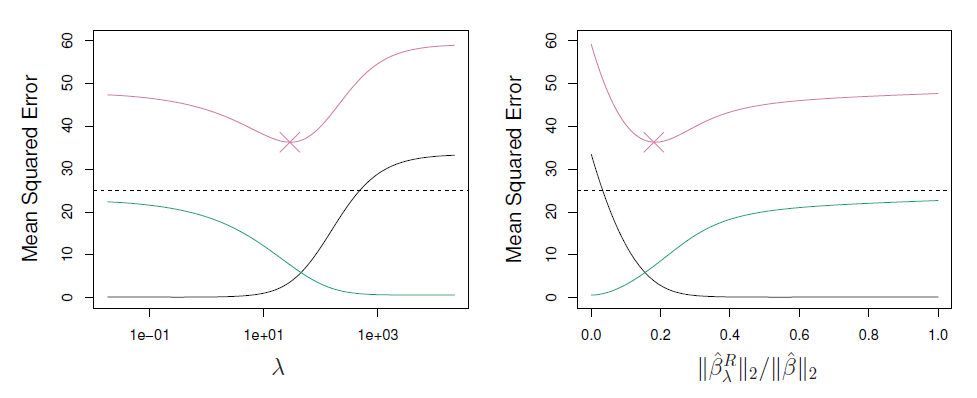

### Lasso 

Ridge regression은 $\lambda$에 따라 coefficient들의 값을 0에 가깝게 보내기는 하지만 완전히 0이 되는 것이 아니기 때문에 최종 모형에는 결국 총 $p$개의 predictor들이 모두 포함된다.

Lasso는 ridge의 대안으로, 다음을 최소화하는 $\beta$들을 찾으며 이를 $\hat \beta_\lambda^L$이라고 하겠다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} |\beta_j| = \mathrm{RSS} + \lambda \sum_{j=1}^{p} |\beta_j| $$

통계적 용어로 이야기하자면, lasso는 $\ell_1$ penalty를 사용하고 ridge는 $\ell_2$ penaltiy를 사용하는 것이다.

Ridge와 마찬가지로 lasso 또한 coefficient 추정치를 0으로 보내지만 ridge와 달리 $\lambda$가 충분히 크면 완전히 0의 값이 된다.

따라서 lasso는 일종의 variable selection 역할을 한다.

Lasso는 sparse 모형을 만들어낸다고도 한다.

마찬가지로 적절한 $\lambda$의 값을 선택하는 것이 중요하며 cross-validation 방법이 이용된다.

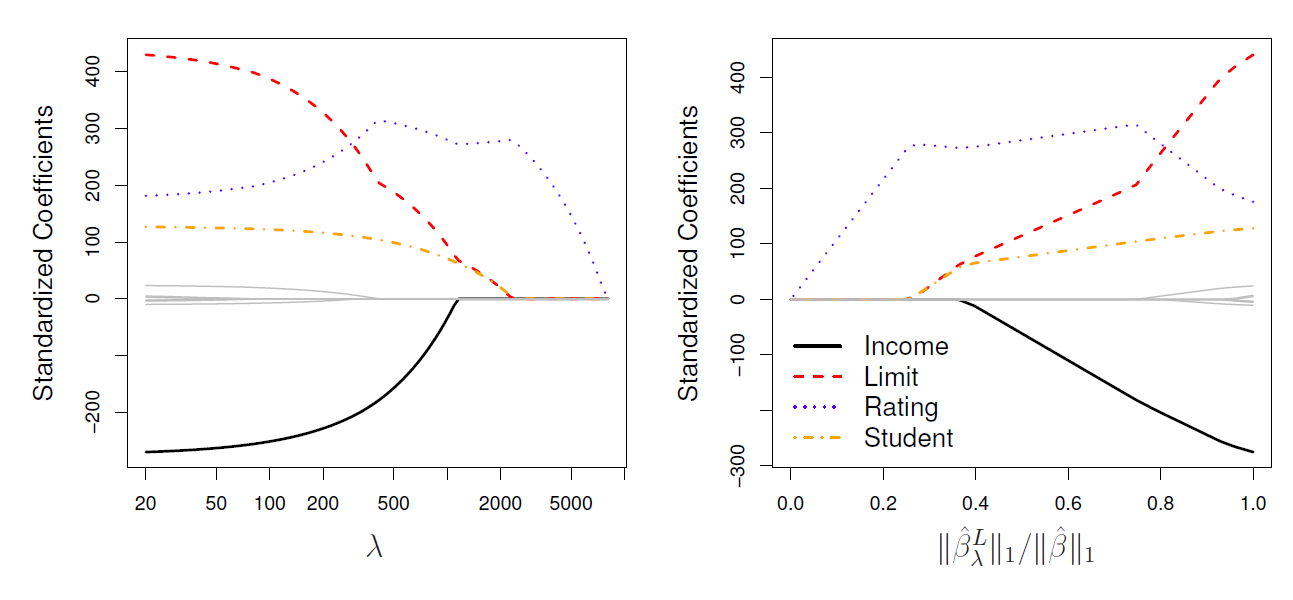

정규화 강도가 커질수록 회귀계수의 절댓값이 작아진다. Lasso에서는 (Ridge와 달리) 일부 계수가 정확히 0이 될 수 있다.

### Ridge와 Lasso의 차이

Lasso와 ridge regression은 각각 결국 다음의 문제를 해결하는 것과 같다.

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} |\beta_j| \leq s $$

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} \beta_j^2 \leq s $$

그림으로 표현하자면 다음과 같으며, 단순히 Ridge와 Lasso 중 어느 것이 더 낫다고 결론을 지을 수는 없다.

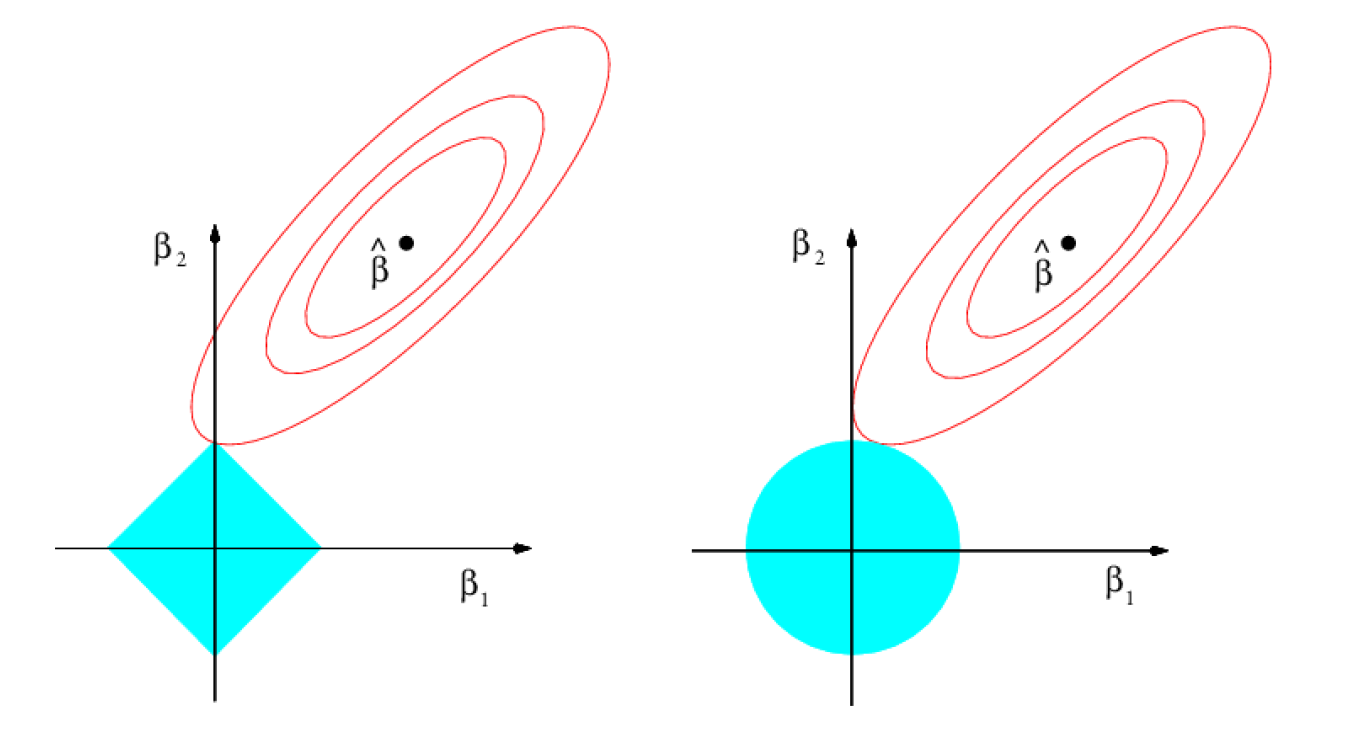

### 모형 선택

앞서 이야기했듯이 $\lambda$는 cross-validation 방법을 통해 정하는 것이 바람직하다.

아래는 먼저 다양한 $\lambda$에 대해 ridge regression을 적합하고, 테스트 자료에서의 MSE를 계산하여 계수와 오차가 $\lambda$에 따라 어떻게 변하는지 살펴보는 예제이다.

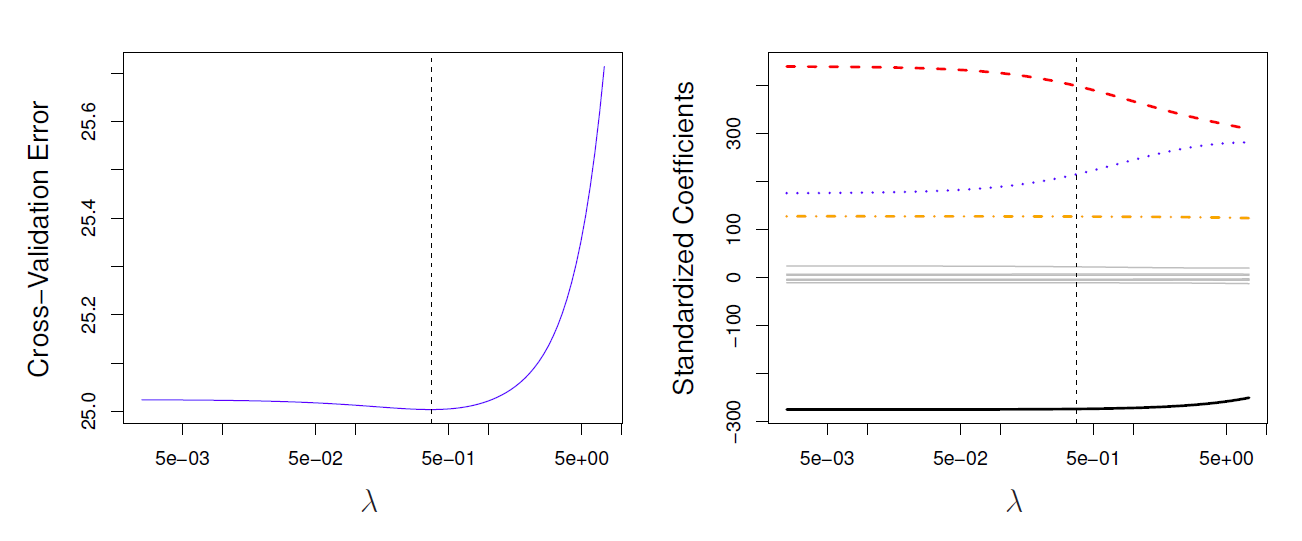

아래는 lasso에 대해서도 마찬가지로, 다양한 $\lambda$에 대해 계수와 테스트 자료에서의 MSE가 어떻게 변하는지 살펴보는 예제이다.

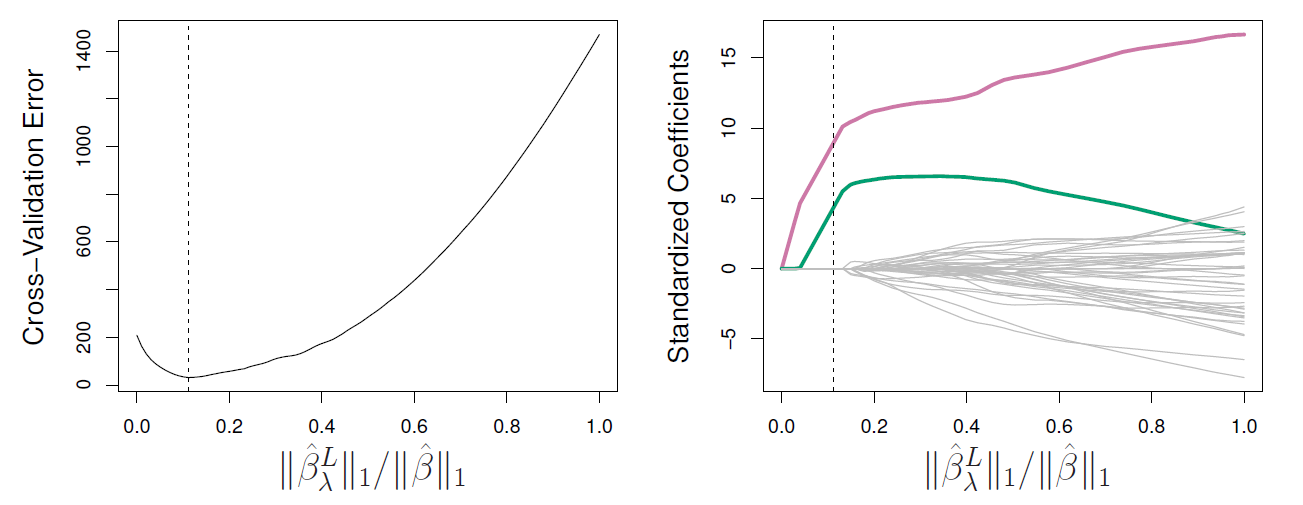

### 엘라스틱넷 (elastic net)

Ridge와 Lasso를 절충한 모델.

그 목적함수는 다음과 같다:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 
+ \lambda \left( r \sum_{j=1}^{p} |\beta_j| + \frac{1 - r}{2} \sum_{j=1}^{p} \beta_j^2 \right)
$$

여기서,

* $\lambda$는 **전체 정규화 강도**를 조절하는 하이퍼파라미터이고,
* $r \in [0, 1]$은 **Lasso와 Ridge 사이의 혼합 비율**이다.

  * $r = 1$이면 Lasso,
  * $r = 0$이면 Ridge,
  * $0 < r < 1$이면 두 기법을 혼합한 형태가 된다.


## Hitter example

여러 지표를 바탕으로 야구(타자) 선수의 연봉을 예측하는 문제.

이 자료는 통산 기록(`CAtBat`, `CHits`, `CRuns`, `CRBI`, `CWalks` 등)과 최근 시즌 기록이 서로 강하게 상관되어 있어, Ridge와 Lasso 같은 정규화 기법이 특히 유용한 대표적인 예로 자주 사용된다.

여기서는 예제를 단순화하기 위해 범주형 변수를 제외한다. 실제 분석에서는 one-hot encoding을 적용하여 포함할 수 있다.

In [1]:
import pandas as pd
df = pd.read_csv('https://gist.githubusercontent.com/keeganhines/59974f1ebef97bbaa44fb19143f90bad/raw/d9bcf657f97201394a59fffd801c44347eb7e28d/Hitters.csv')
df = df.dropna(axis=0)
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
5,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,...,501,336,194,A,W,282,421,25,750.0,A


In [2]:
from sklearn.model_selection import train_test_split

y = df["Salary"]
X = df.iloc[:, 1:]
X = X.drop(["Salary", "League", "Division", "NewLeague"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [3]:
from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale.fit(X_train)
X_train_std = std_scale.transform(X_train)
X_test_std = std_scale.transform(X_test)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_std, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-506.27, 553.32, -18.3 ,..., 109.35, 54.2 , 10.5 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,571.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,16
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[37.62,28.91,18.21,..., 1.65, 0.96, 0.49]"


In [5]:
print(lr.coef_, lr.intercept_)

[-506.27166727  553.32129117  -18.30338337 -118.51098002   47.61085711
  162.170604    -28.82545063 -188.57378943 -300.89552919   48.11595165
  778.17788335  157.17820824 -272.43172045  109.34672097   54.19829248
   10.50179446] 571.4687309644671


### Ridge

[```sklearn.linear_model.Ridge```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

minimize ```||y - Xw||^2_2 + alpha * ||w||^2_2```

scikit-learn에서는 정규화 강도를 `alpha`로 지정한다. `alpha`가 클수록 회귀계수가 더 많이 축소된다.

In [6]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_train_std, y_train)
print(ridge.coef_, ridge.intercept_)

[-413.02663203  426.96601361  -39.49631078  -52.48276454   62.33393395
  136.90463205  -47.60615147 -182.88424078   45.47063257  125.50554814
  423.46737773   28.93538082 -182.4808891   104.22349553   48.4703636
    4.62227951] 571.4687309644671


다양한 튜닝 파라미터 `alpha`에 대해 진행해 보자.

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_std, y_train)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))

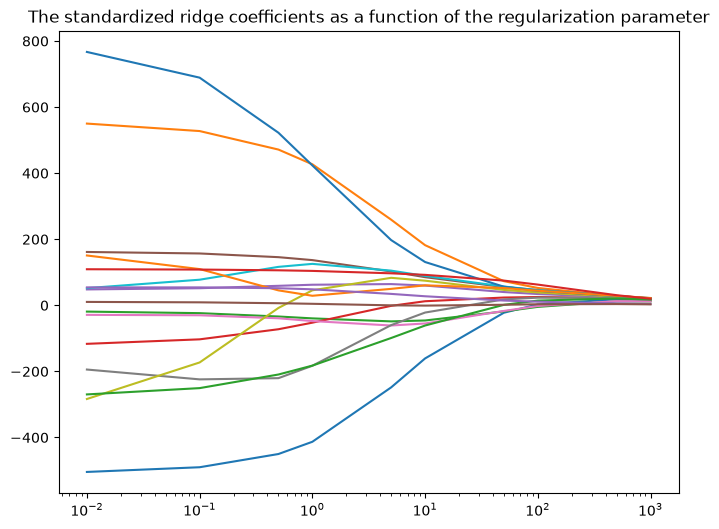

In [8]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

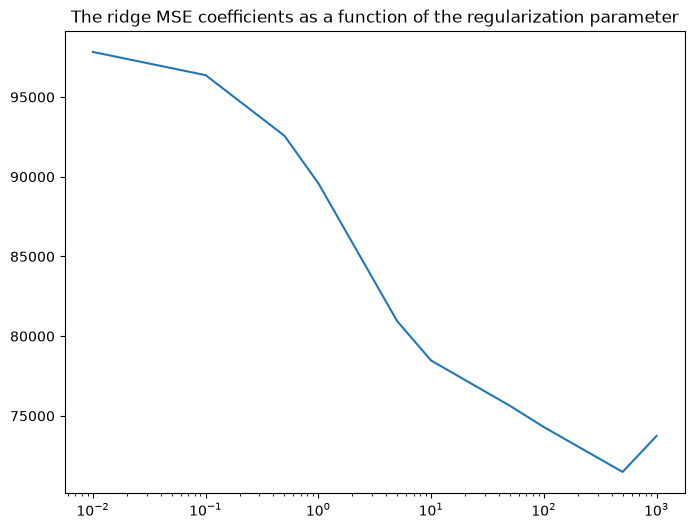

In [9]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### Lasso

[```sklearn.linear_model.Lasso```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

다음을 최소화한다.

minimize 1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1

In [10]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 1) 
lasso.fit(X_train_std, y_train)
print(lasso.coef_, lasso.intercept_)

[-458.71676426  480.20620652  -30.2889187   -67.43326297   54.53675438
  144.30487011  -38.4502154  -180.89585229   -0.          134.92516409
  498.9796067     0.         -205.2875054   105.86404308   50.32241085
    6.37331886] 571.4687309644671


In [11]:
L_coefs = []
L_errs = []

alphas = np.array([0.5, 1, 2.5, 5, 10, 25, 50, 100])

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=2000)
    lasso.fit(X_train_std, y_train)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_test, lasso.predict(X_test_std)))

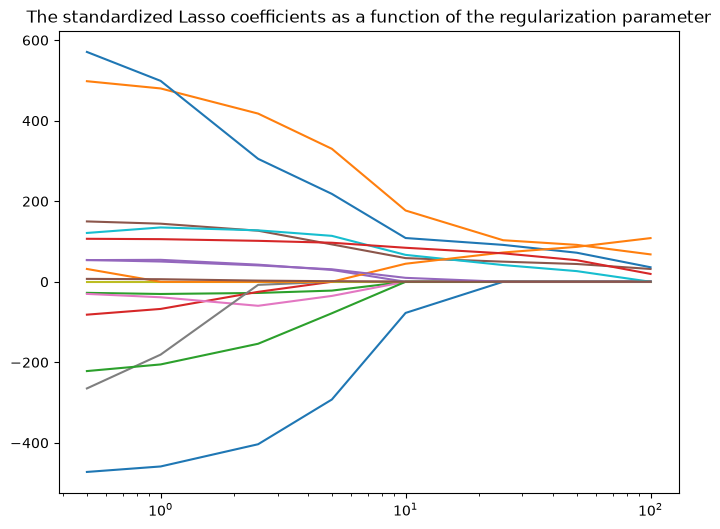

In [12]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

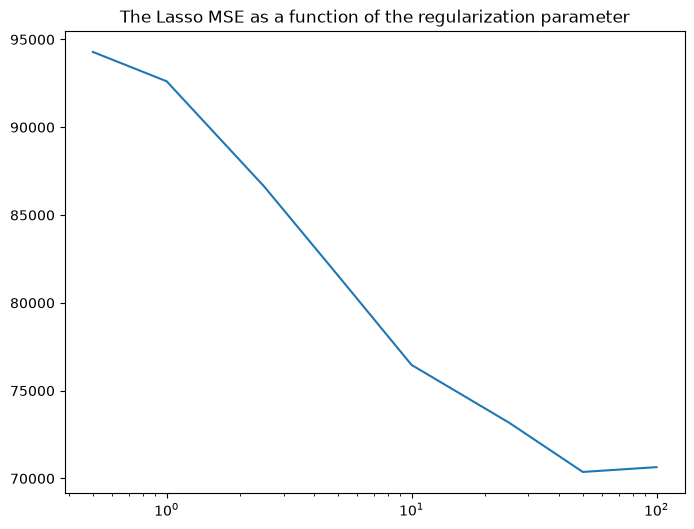

In [13]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### sklearn에서의 ElasticNet

[```sklearn.linear_model.ElasticNet```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

minimize 1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

In [14]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic.fit(X_train_std, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [15]:
print(elastic.coef_, elastic.intercept_)

[ 2.39536751 52.90105545 -4.00021901 24.91715395 33.89835067 46.55091571
 -1.12630294 22.93673701 38.88265242 45.57332507 43.97754003 44.11384778
 13.86729634 62.77834469 10.9355182   3.04556851] 571.4687309644671


### Cross-validation

Ridge regression을 이용하여 앞에서 했던 내용을 반복해 보자.

아래 코드는 각 alpha 후보에 대해 (표준화 + Ridge) pipeline을 5-fold cross-validation으로 평가하여, 5개 fold의 평균 MSE가 가장 작은 alpha를 찾는다.

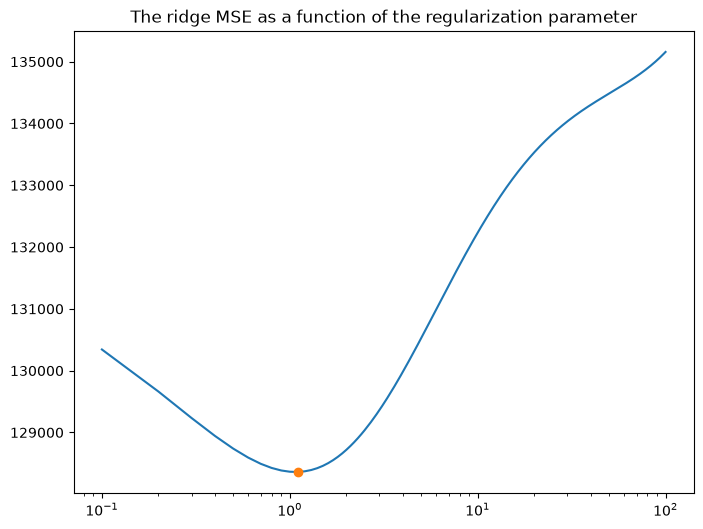

In [16]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
alphas = np.arange(0.1, 100, 0.1)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))

ridge_best_alpha = alphas[np.argmin(errs_alpha)]

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso regression을 이용하여 같은 방법을 다시 적용하여 보았다.

In [17]:
from sklearn.model_selection import KFold
alphas = np.arange(1, 10, 0.02)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Lasso 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=2000))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


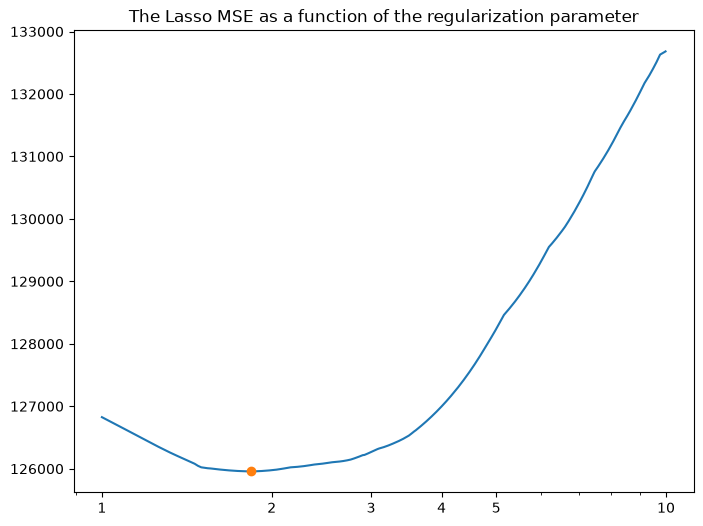

In [18]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

lasso_best_alpha = alphas[np.argmin(errs_alpha)]

plt.xticks([1, 2, 3, 4, 5, 10], ['1', '2', '3', '4', '5', '10'])

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Elastic Net을 이용하여 같은 방법을 다시 적용하여 보았다.

In [19]:
from sklearn.linear_model import ElasticNet
alphas = np.logspace(-4, 1.3, 200)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:

    # 파이프라인: 표준화 + ElasticNet 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('elastic', ElasticNet(alpha=a, l1_ratio=0.5, max_iter=2000))
    ])

    neg_mse_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')

    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.462153e+06, tolerance: 4.056e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.653084e+06, tolerance: 3.421e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.589275e+06, tolerance: 3.418e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.235125e+06, tolerance: 3.471e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.438988e+06, tolerance: 3.418e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.070549e+06, tolerance: 3.471e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.265986e+06, tolerance: 4.056e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.379548e+06, tolerance: 3.421e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.687245e+06, tolerance: 3.991e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.864472e+06, tolerance: 4.056e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.356218e+06, tolerance: 3.991e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.481713e+06, tolerance: 4.056e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.779553e+05, tolerance: 4.056e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.311007e+05, tolerance: 3.421e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

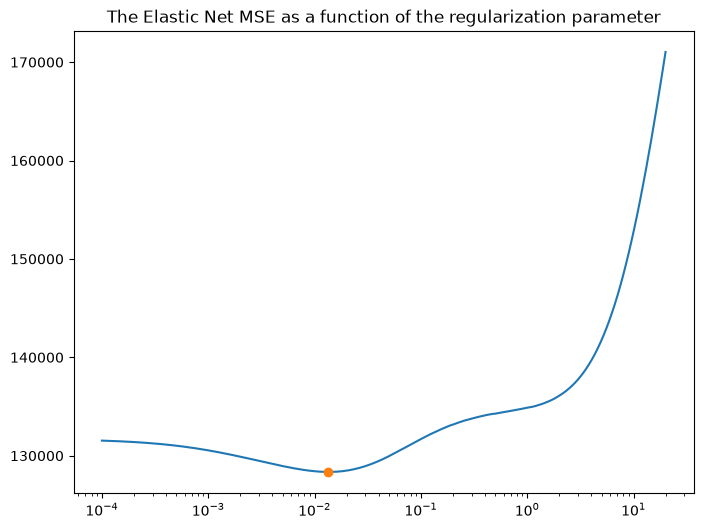

In [20]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

elastic_best_alpha = alphas[np.argmin(errs_alpha)]

plt.title("The Elastic Net MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Cross-validation으로 선택한 alpha로 각 모형을 `X_train`에 다시 적합하고, 지금까지 사용하지 않은 `X_test`에서 최종 성능을 비교해 보자.

In [21]:
ridge_final = Ridge(alpha=ridge_best_alpha).fit(X_train_std, y_train)
lasso_final = Lasso(alpha=lasso_best_alpha, max_iter=2000).fit(X_train_std, y_train)
elastic_final = ElasticNet(alpha=elastic_best_alpha, l1_ratio=0.5, max_iter=2000).fit(X_train_std, y_train)

from sklearn.metrics import mean_squared_error

print("Linear regression test MSE:", mean_squared_error(y_test, lr.predict(X_test_std)))
print(f"Ridge test MSE (alpha={ridge_best_alpha:.4f}):", mean_squared_error(y_test, ridge_final.predict(X_test_std)))
print(f"Lasso test MSE (alpha={lasso_best_alpha:.4f}):", mean_squared_error(y_test, lasso_final.predict(X_test_std)))
print(f"Elastic Net test MSE (alpha={elastic_best_alpha:.4f}):", mean_squared_error(y_test, elastic_final.predict(X_test_std)))

Linear regression test MSE: 98031.64423601986
Ridge test MSE (alpha=1.1000): 89110.66880556897
Lasso test MSE (alpha=1.8400): 89053.42502937664
Elastic Net test MSE (alpha=0.0135): 88091.40545472043
